# ***Load Libraries***

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [92]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [93]:
df.shape

(20640, 10)

In [94]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [95]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [97]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [98]:
df.describe(include="object")

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.isna().sum()/df.shape[0]*100

,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,1.002907
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


In [101]:
(df == 0).sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [102]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [103]:
num_df = df.select_dtypes(include = "number")
cat_df = df.select_dtypes(include = "object")

In [104]:
num_df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [105]:
num_df.cov()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,4.014139,-3.957054,-2.728244,1.948037e+02,5.876851e+01,2.263778e+02,4.236807e+01,-0.057765,-1.062743e+04
latitude,-3.957054,4.562293,0.300346,-1.682178e+02,-6.029962e+01,-2.631378e+02,-5.801024e+01,-0.323860,-3.553256e+04
housing_median_age,-2.728244,0.300346,158.396260,-9.919120e+03,-1.700313e+03,-4.222271e+03,-1.457581e+03,-2.846140,1.533988e+05
total_rooms,194.803750,-168.217847,-9919.120060,4.759445e+06,8.567306e+05,2.117613e+06,7.661046e+05,820.852410,3.377289e+07
total_bedrooms,58.768508,-60.299623,-1700.312817,8.567306e+05,1.775654e+05,4.191391e+05,1.578295e+05,-6.180851,2.416878e+06
population,226.377839,-263.137814,-4222.270582,2.117613e+06,4.191391e+05,1.282470e+06,3.928036e+05,10.400979,-3.221249e+06
households,42.368072,-58.010245,-1457.581290,7.661046e+05,1.578295e+05,3.928036e+05,1.461760e+05,9.466667,2.904924e+06
median_income,-0.057765,-0.323860,-2.846140,8.208524e+02,-6.180851e+00,1.040098e+01,9.466667e+00,3.609323,1.508475e+05
median_house_value,-10627.425205,-35532.559074,153398.801329,3.377289e+07,2.416878e+06,-3.221249e+06,2.904924e+06,150847.482793,1.331615e+10


In [106]:
num_df.skew()

,0
longitude,-0.297801
latitude,0.465953
housing_median_age,0.060331
total_rooms,4.147343
total_bedrooms,3.459546
population,4.935858
households,3.410438
median_income,1.646657
median_house_value,0.977763


In [107]:
num_df.kurtosis()

,0
longitude,-1.330152
latitude,-1.117760
housing_median_age,-0.800629
total_rooms,32.630927
total_bedrooms,21.985575
population,73.553116
households,22.057988
median_income,4.952524
median_house_value,0.327870


In [108]:
num_df.quantile([0.25, 0.5, 0.75, 0.95, 0.99])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0.25,-121.80,33.9300,18.0,1447.75,296.00,787.00,280.00,2.563400,119600.0
0.50,-118.49,34.2600,29.0,2127.00,435.00,1166.00,409.00,3.534800,179700.0
0.75,-118.01,37.7100,37.0,3148.00,647.00,1725.00,605.00,4.743250,264725.0
0.95,-117.08,38.9600,52.0,6213.20,1275.40,3288.00,1162.00,7.300305,489810.0
0.99,-116.29,40.6261,52.0,11212.11,2221.36,5805.83,1982.66,10.596540,500001.0


In [109]:
df.groupby('median_income')["median_house_value"].mean()

,median_house_value
median_income,
0.4999,163608.500000
0.5360,166999.900000
0.5495,91700.000000
0.6433,111300.000000
0.6775,350000.000000
...,...
14.4219,500001.000000
14.5833,500001.000000
14.9009,500001.000000


In [110]:
df.groupby('total_rooms')["households"].max()

,households
total_rooms,
2.0,2.0
6.0,2.0
8.0,1.0
11.0,13.0
12.0,7.0
...,...
30450.0,3197.0
32054.0,5050.0
32627.0,6082.0


In [111]:
df.groupby('ocean_proximity')['median_house_value'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
ocean_proximity,,,,
<1H OCEAN,240084.285464,214850.0,106124.292213,9136
INLAND,124805.392001,108500.0,70007.908494,6551
ISLAND,380440.000000,414700.0,80559.561816,5
NEAR BAY,259212.311790,233800.0,122818.537064,2290
NEAR OCEAN,249433.977427,229450.0,122477.145927,2658


In [112]:
df.nunique()

,0
longitude,844
latitude,862
housing_median_age,52
total_rooms,5926
total_bedrooms,1923
population,3888
households,1815
median_income,12928
median_house_value,3842
ocean_proximity,5


# *Data Visualization*

<Axes: >

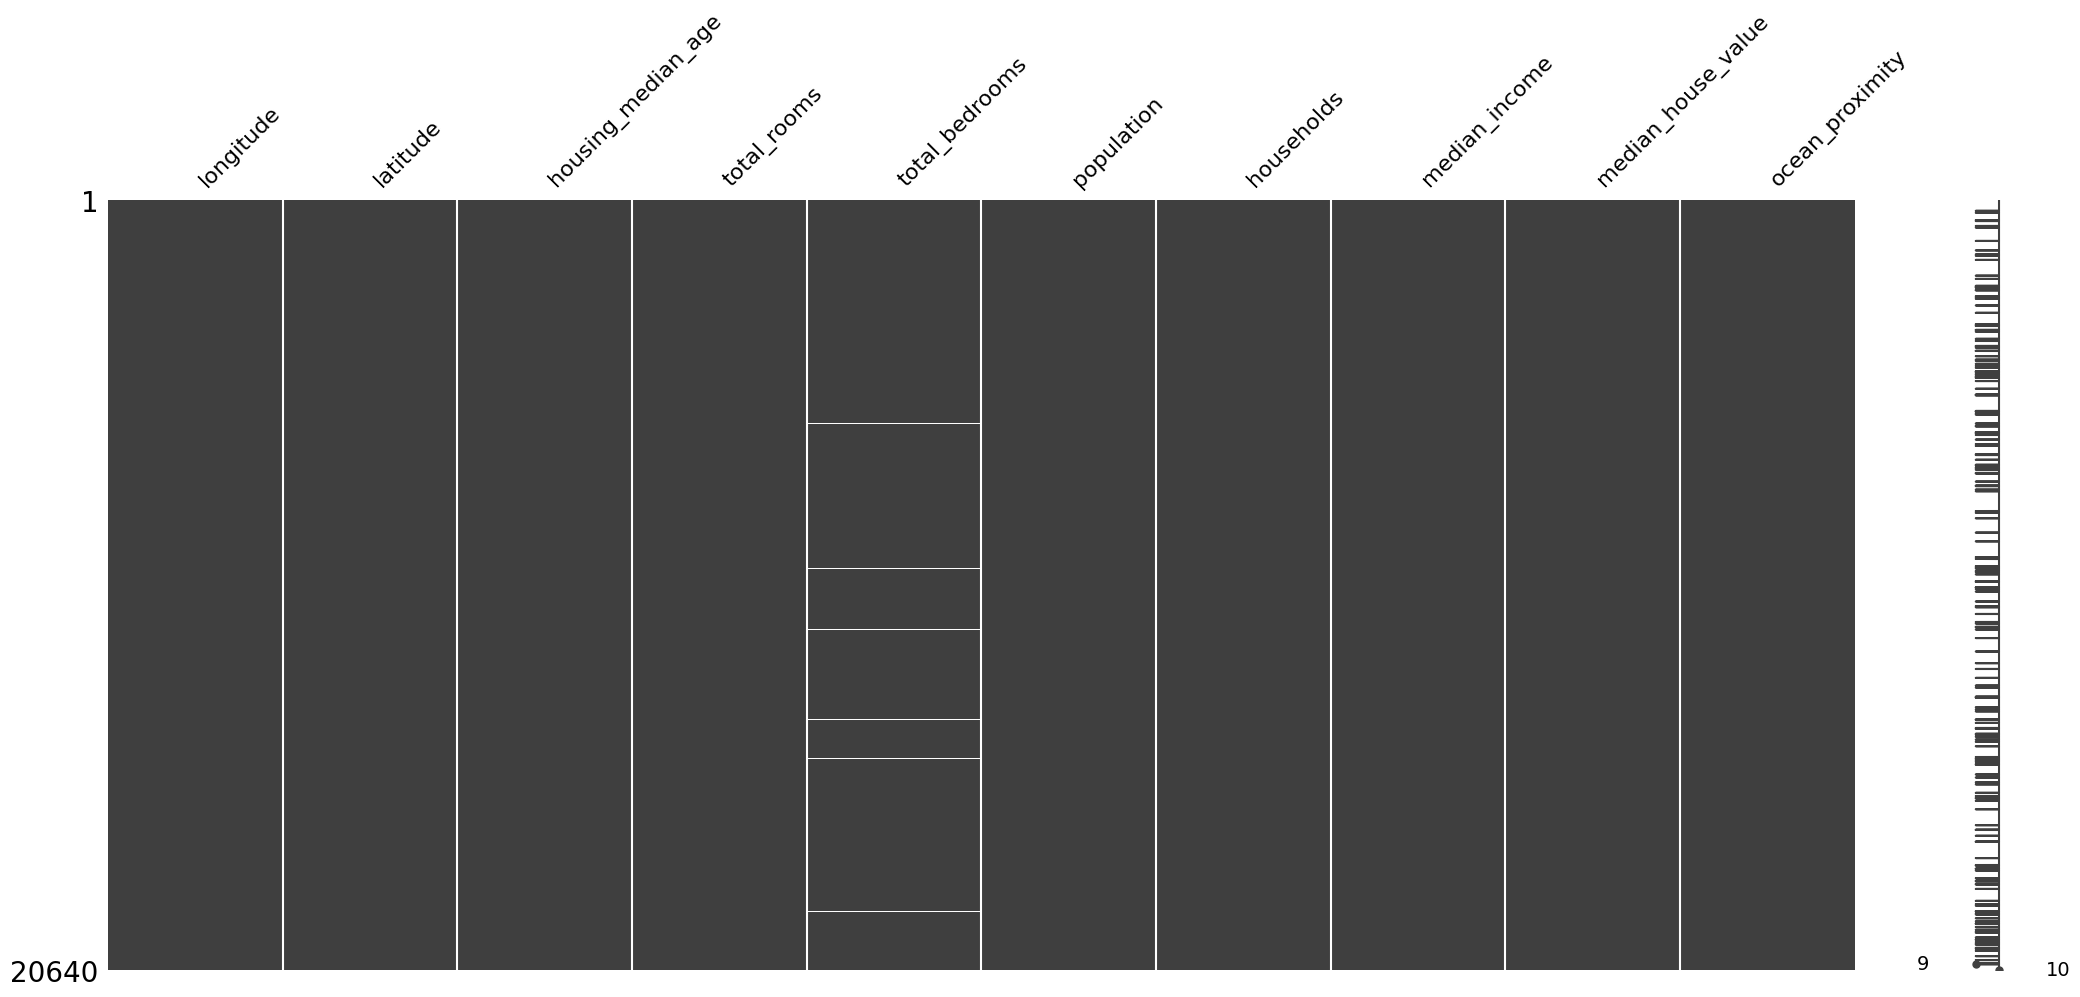

In [113]:
import missingno as msno
msno.matrix(df)

<Axes: >

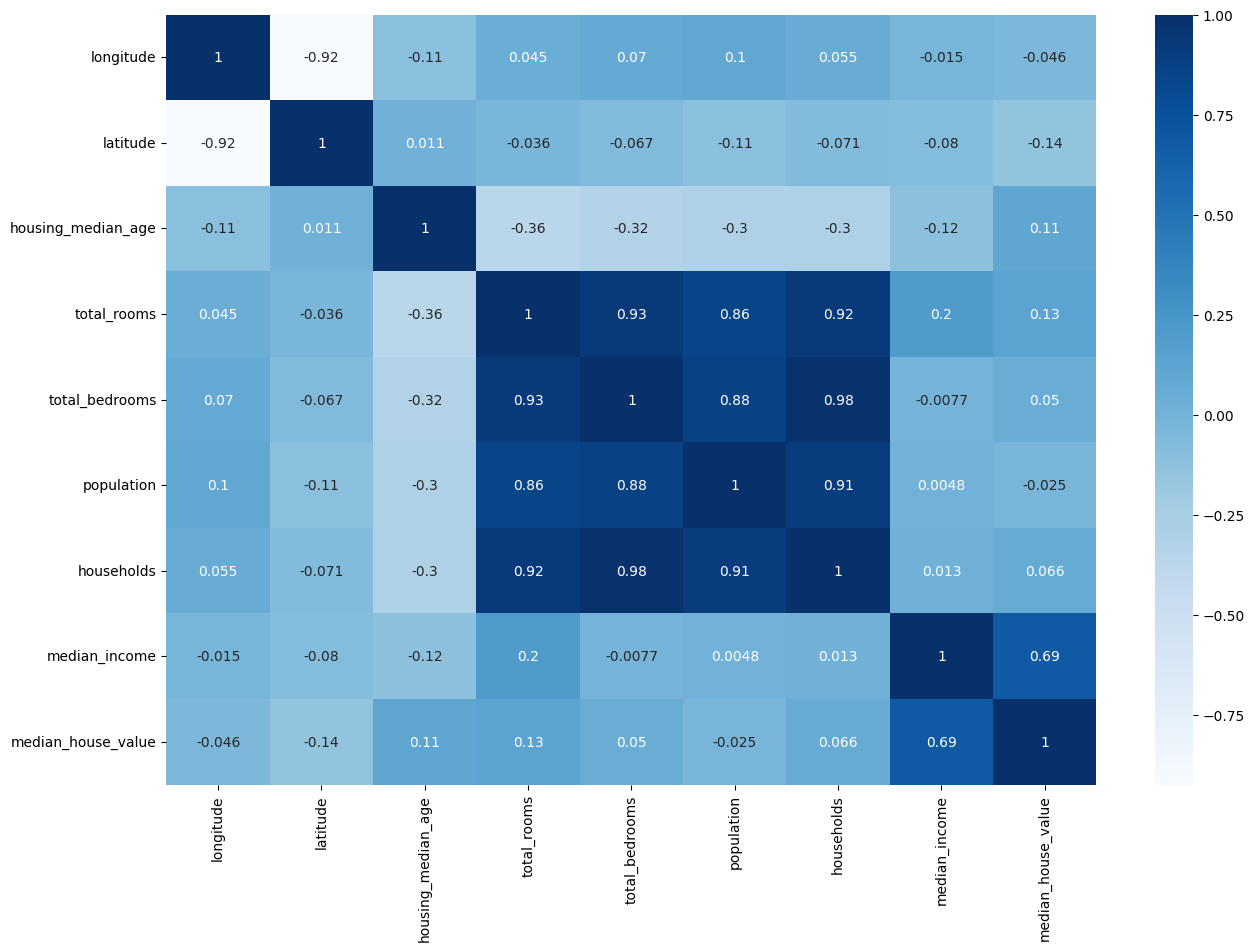

In [114]:
plt.figure(figsize=(15,10))
sns.heatmap(num_df.corr(),annot=True,cmap="Blues")

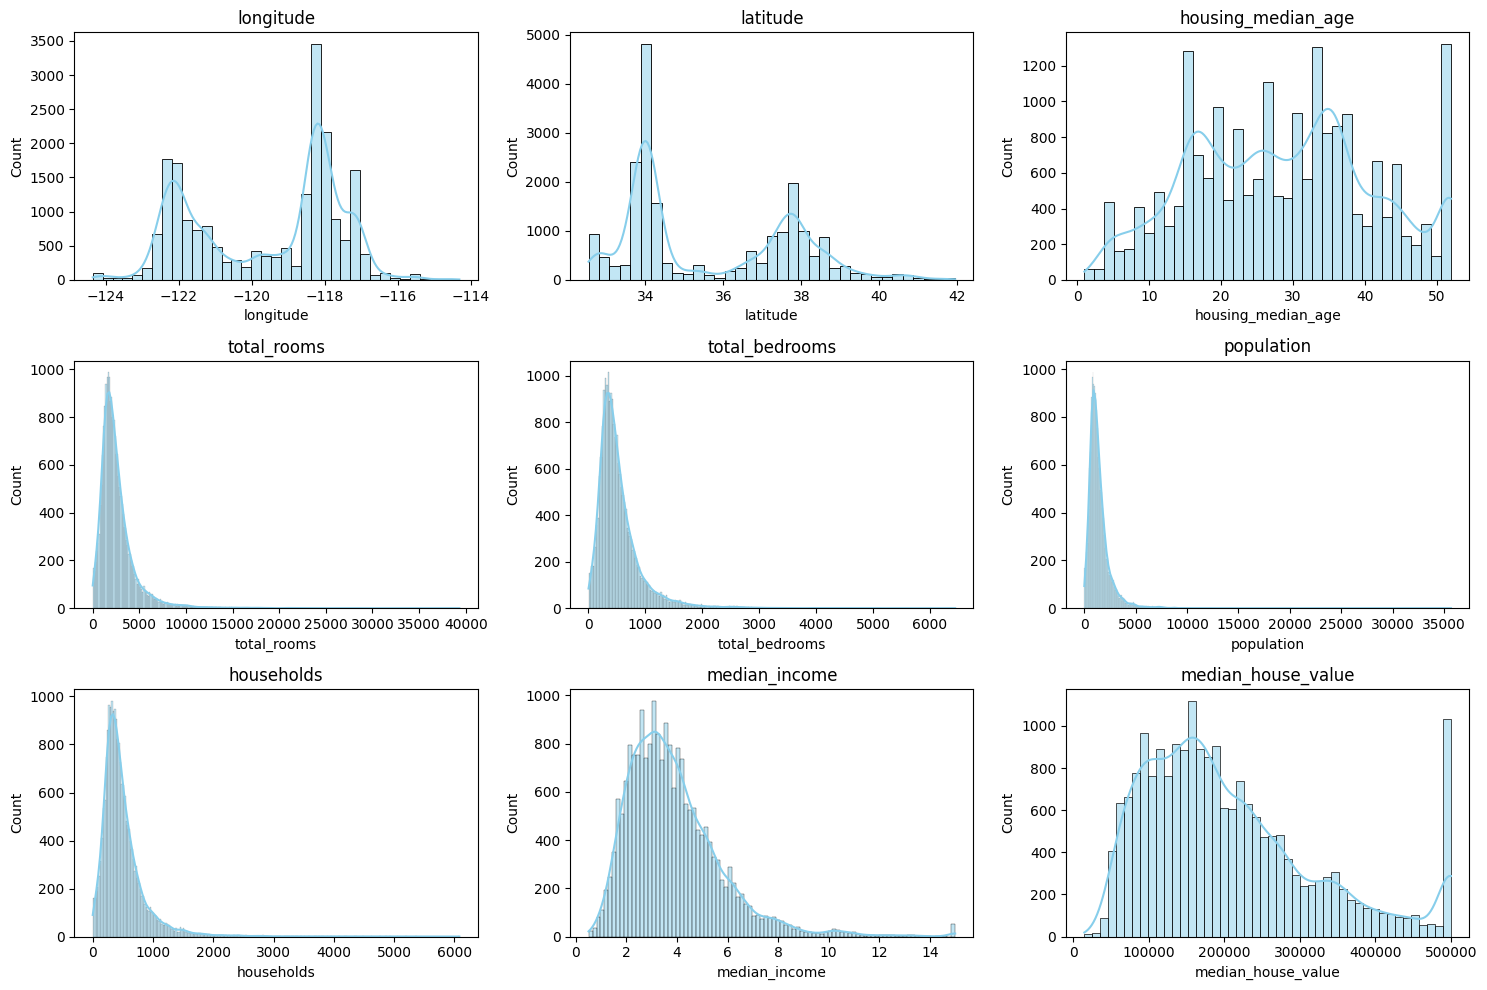

In [115]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_df):
    sns.histplot(num_df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

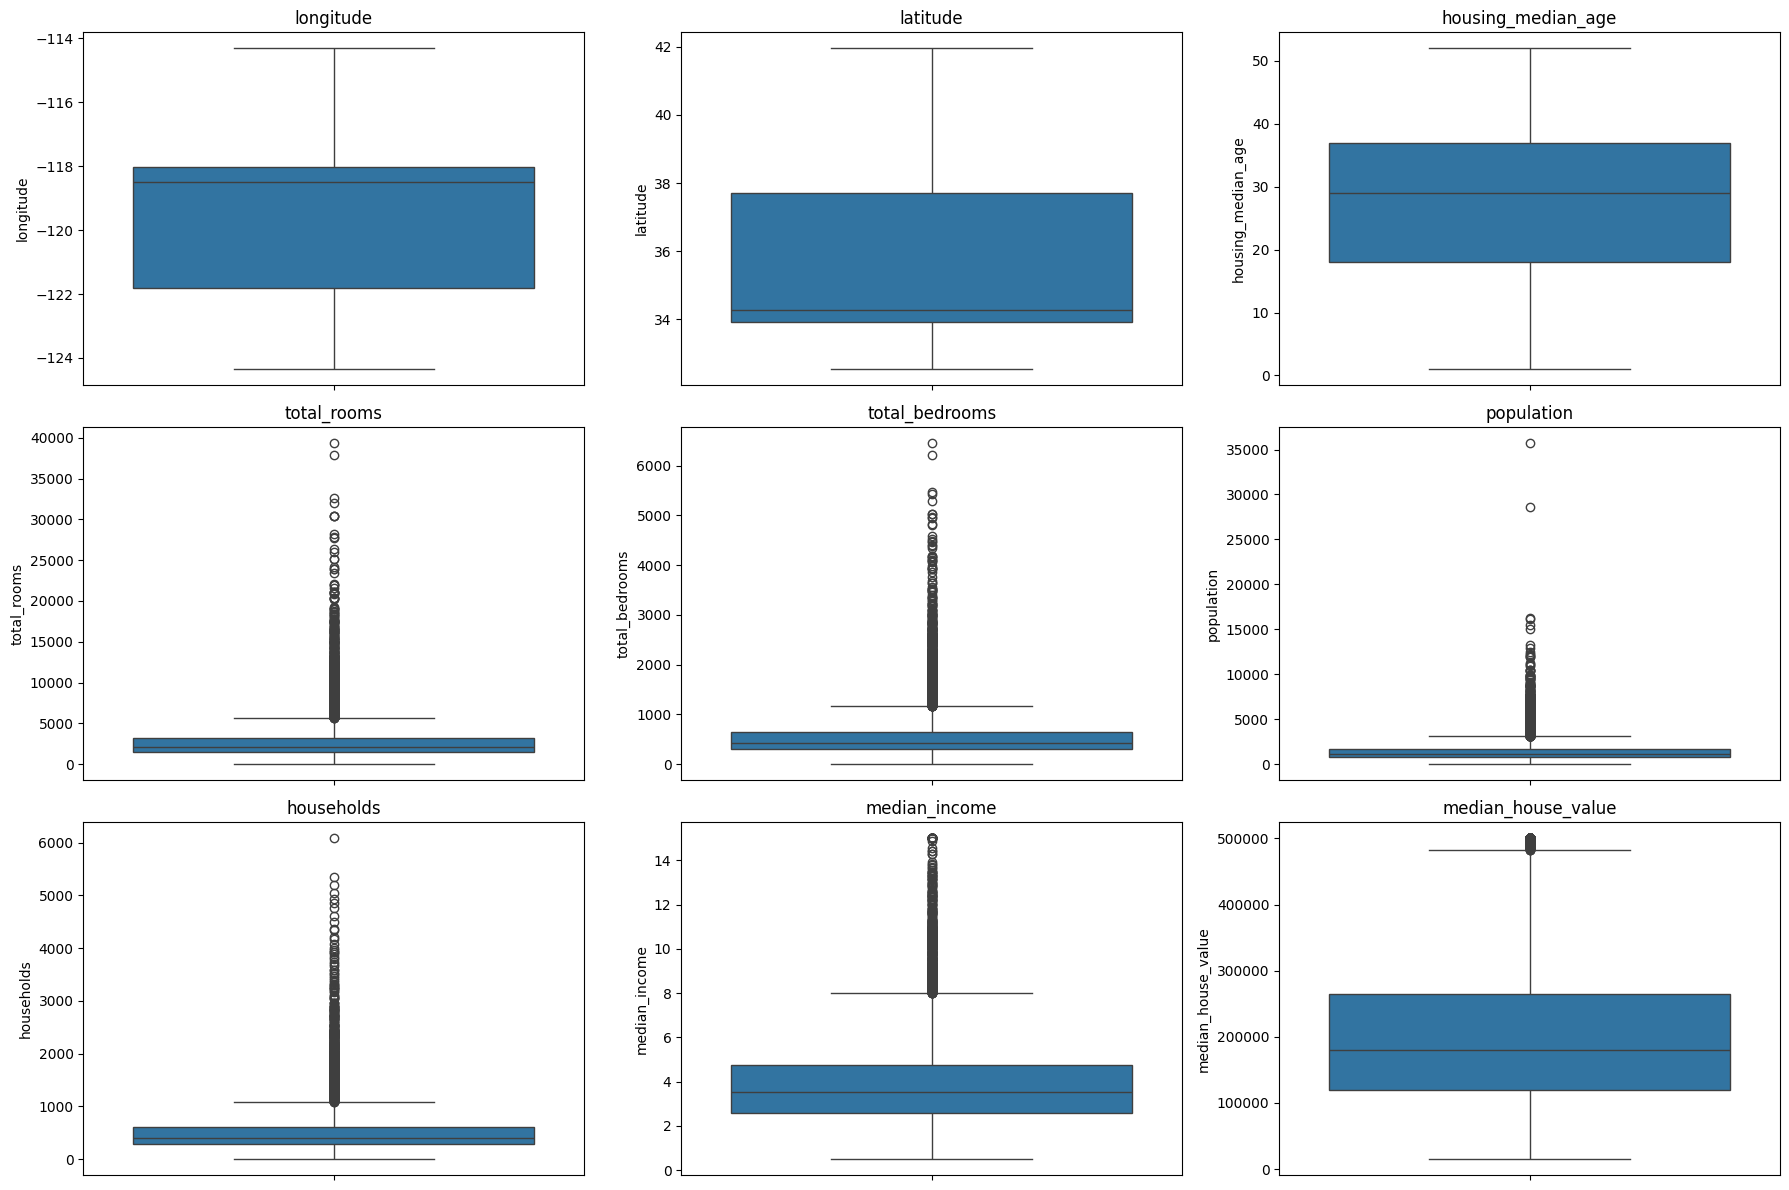

In [116]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_df):
    sns.boxplot(y=num_df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

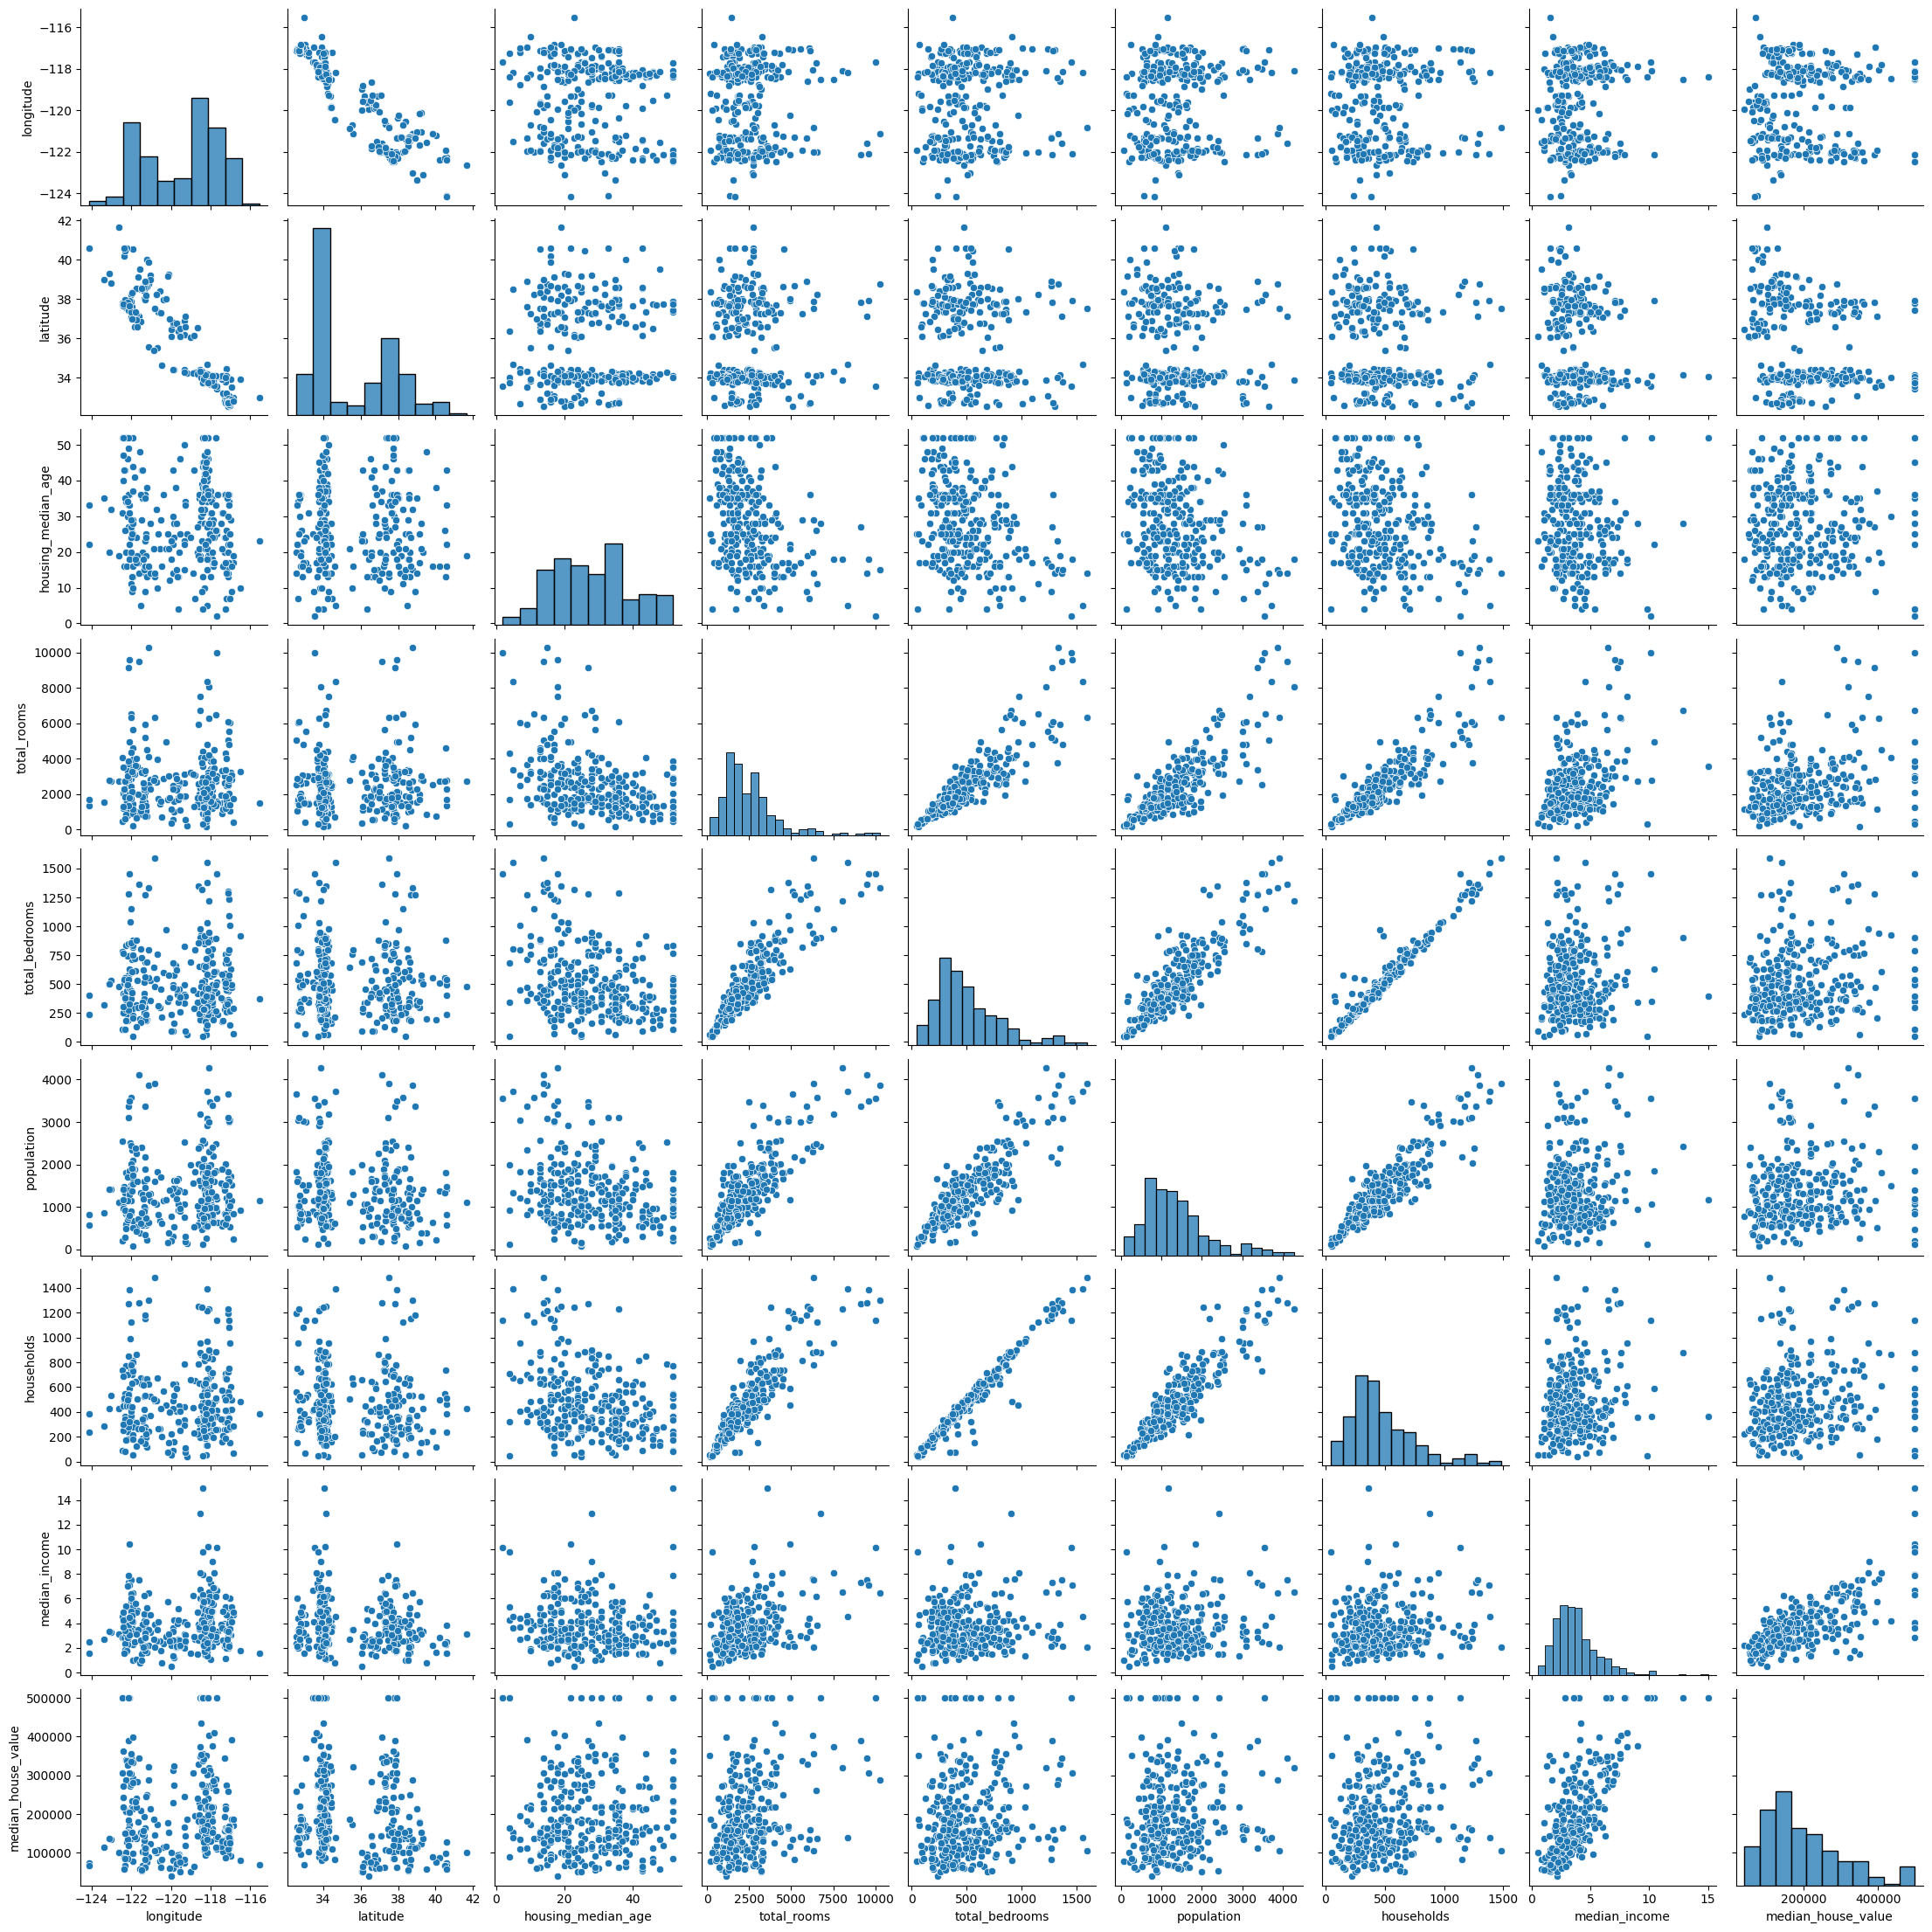

In [117]:
sns.pairplot(num_df.sample(300))

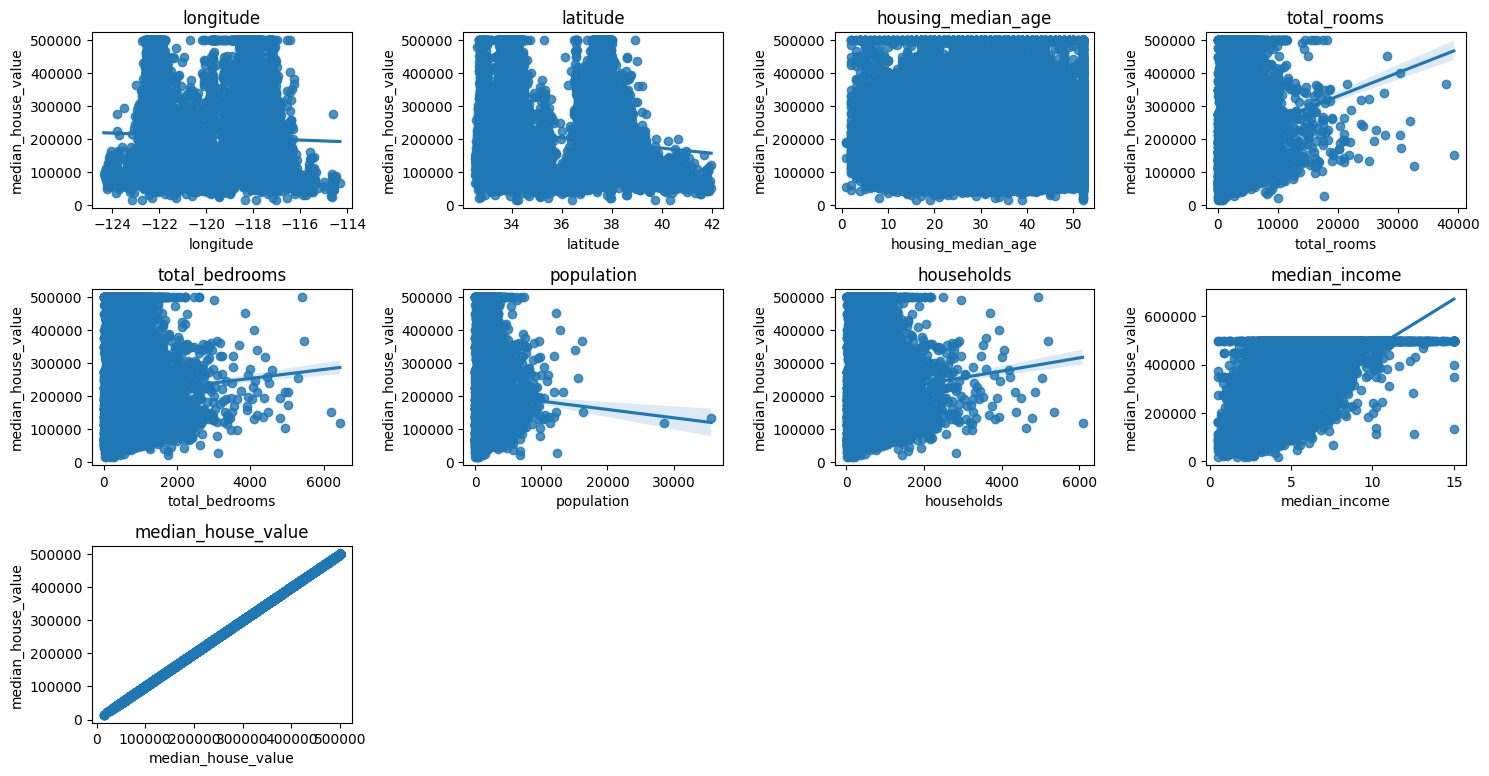

In [118]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_df):
    plt.subplot(4, 4, i+1)
    sns.regplot(x=df[col], y=df["median_house_value"])
    plt.title(col)
plt.tight_layout()
plt.show()

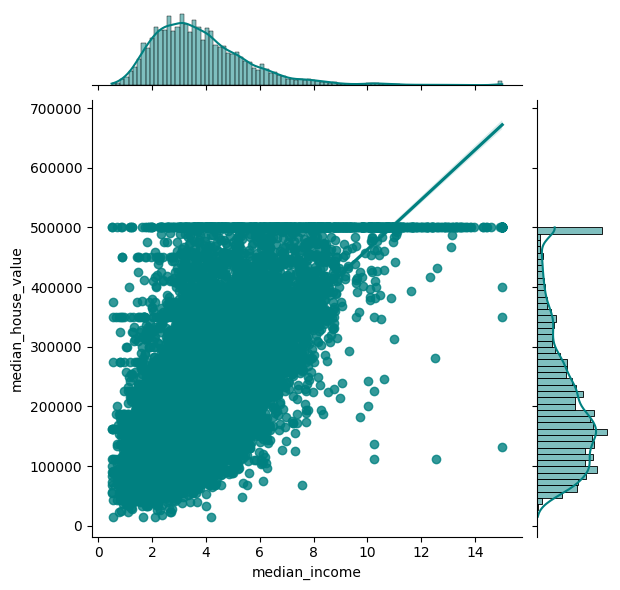

In [119]:
sns.jointplot(data=df, x='median_income', y='median_house_value', kind='reg', color='teal')
plt.show()

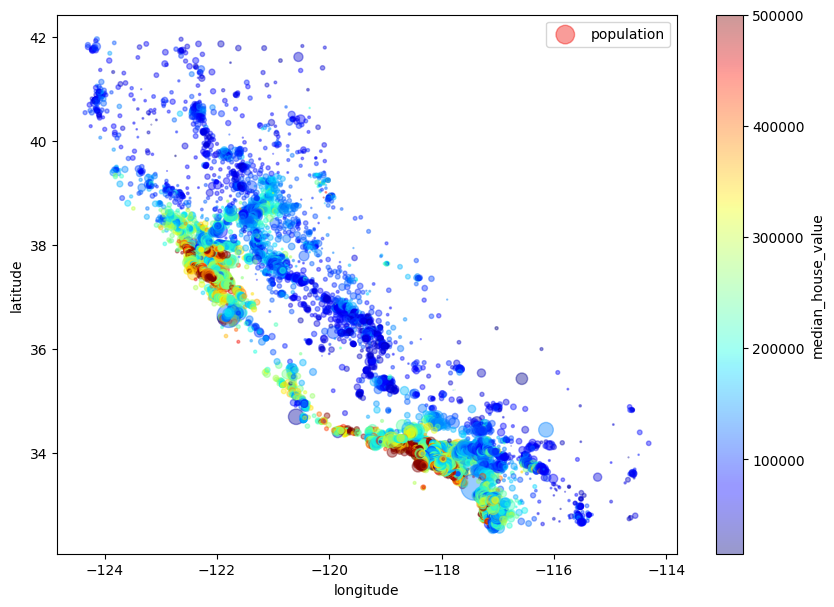

In [120]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=df["population"]/100, label="population", figsize=(10,7),
        c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

Text(0, 0.5, 'Count')

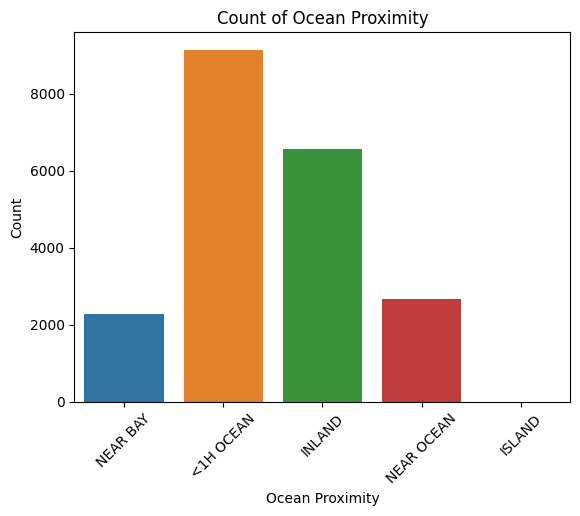

In [121]:
sns.countplot(data=cat_df, x="ocean_proximity",hue="ocean_proximity")
plt.title("Count of Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.xticks(rotation=45)
plt.ylabel("Count")

# ***Data Preprocessing***


In [122]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [123]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)


In [124]:
mapping = {
    '<1H OCEAN': 1,
    'INLAND': 2,
    'NEAR OCEAN': 3,
    'NEAR BAY': 4,
    'ISLAND': 5
}
df['ocean_proximity'] = df['ocean_proximity'].map(mapping)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,4
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,4
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,4
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,4


In [125]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,int64


In [126]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [129]:
models = {
    "LinearRegression": (
        LinearRegression(),
        {}
    ),

    "Lasso": (
        Lasso(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),

    "Ridge": (
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),

    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [3,5,7,9]}
    ),

    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {"max_depth": [None, 5,10,20]}
    ),

    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100,200],
         "max_depth": [None,10,20]}
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [100,200],
         "learning_rate": [0.01,0.1],
         "max_depth": [3,5]}
    ),

    "AdaBoost": (
        AdaBoostRegressor(random_state=42),
        {"n_estimators": [50,100],
         "learning_rate": [0.01,0.1,1]}
    ),

    "Bagging": (
        BaggingRegressor(random_state=42),
        {"n_estimators": [10,50,100]}
    ),

    "XGBoost": (
        XGBRegressor(random_state=42),
        {"n_estimators": [100,200],
         "learning_rate": [0.01,0.1],
         "max_depth": [3,5]}
    )
}

In [130]:
results = []

for name, (model, params) in models.items():

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_


    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)


    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append([
        name,
        train_r2,
        test_r2,
        train_rmse,
        test_rmse,
        grid.best_params_
    ])


In [134]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Train RMSE",
        "Test RMSE",
        "Best Params"
    ]
)

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Best Params
9,XGBoost,0.887616,0.820256,38759.874196,48532.271541,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
6,GradientBoosting,0.894408,0.814967,37570.412782,49241.070692,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
5,RandomForest,0.975206,0.810271,18205.366797,49862.017235,"{'max_depth': None, 'n_estimators': 200}"
8,Bagging,0.974546,0.808934,18446.167796,50037.453716,{'n_estimators': 100}
3,KNN,0.786514,0.714952,53421.340839,61117.070340,{'n_neighbors': 9}
4,DecisionTree,0.843893,0.706549,45681.618344,62011.349209,{'max_depth': 10}
2,Ridge,0.640326,0.613761,69340.099833,71142.897265,{'alpha': 10}
1,Lasso,0.640334,0.613448,69339.329284,71171.738938,{'alpha': 10}
0,LinearRegression,0.640334,0.613375,69339.273063,71178.472235,{}
7,AdaBoost,0.567678,0.552491,76020.947180,76578.012166,"{'learning_rate': 0.1, 'n_estimators': 50}"


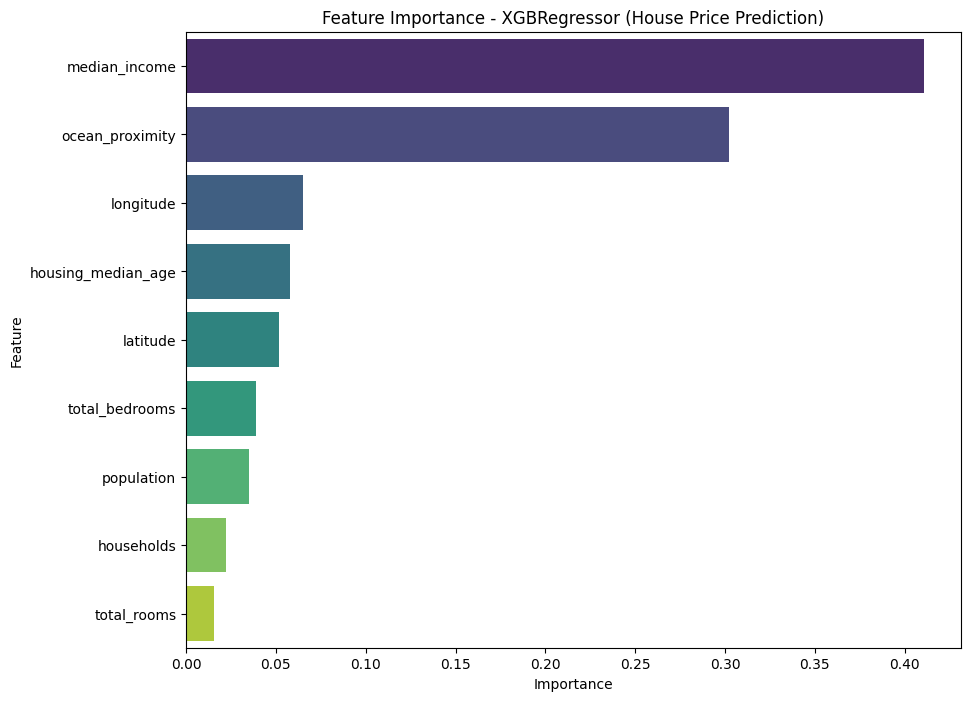

In [135]:
final_model = XGBRegressor(learning_rate= 0.1,max_depth= 5,n_estimators= 200)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

importances = final_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - XGBRegressor (House Price Prediction)')
plt.show()

In [136]:
import joblib

joblib.dump(final_model, 'house_price_prediction.pkl')

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']